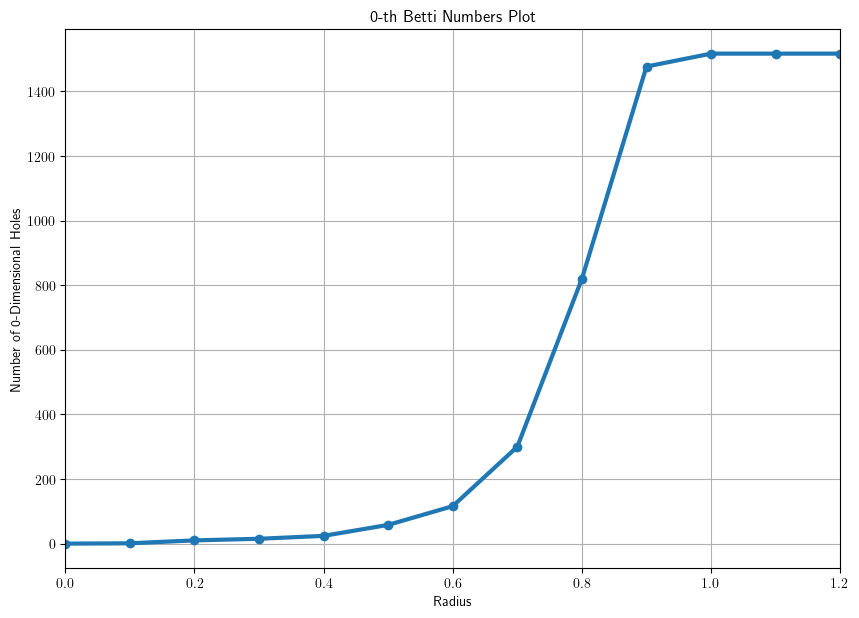

Significant genes saved to: D:\Topologicalcancer-signatures\SignificantGenes.csv


C:\Users\Sudarshan Gogoi\anaconda3\lib\site-packages\gudhi\persistence_graphical_tools.py:105: UserWarning: This function is not available.
ModuleNotFoundError: No module named 'matplotlib'.
  warnings.warn(f"This function is not available.\nModuleNotFoundError: No module named '{import_error.name}'.")


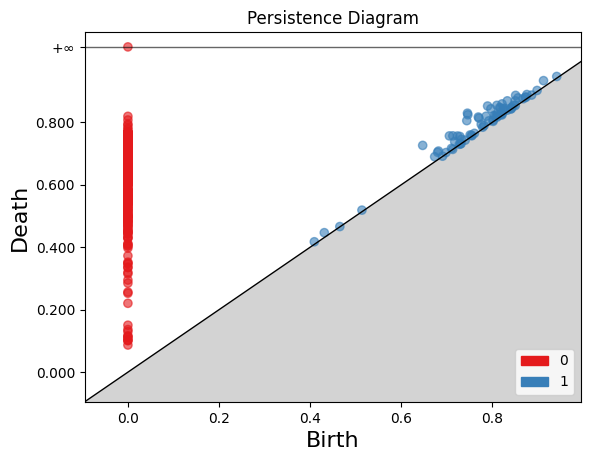

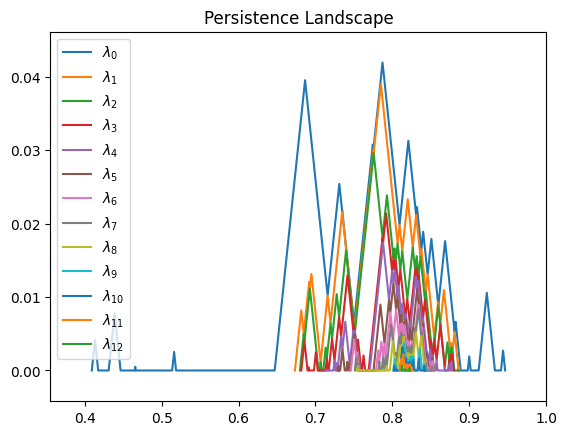

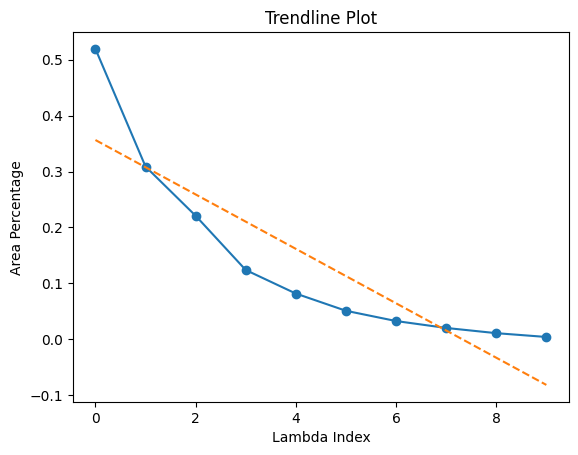

Results saved to: D:\Topologicalcancer-signatures\Topological_Features.xlsx
                                         Feature     Value
0          0-Dimensional Hole Minimum Life Range  0.086866
1          0-Dimensional Hole Maximum Life Range  0.819003
2  Range of Death Values for 0-Dimensional Holes  0.732137
3          1-Dimensional Hole Maximum Life Range  0.083864
4                             Average Birth (1D)  0.770858
5                             Average Death (1D)  0.789723
6                                          Slope -0.048600
7                                      Intercept  0.356220
8                                            R^2  0.777118


In [1]:
# The function- "Extract_Topological_Features" will extract the Topological features & Significant genes (highly correlated genes) of scRNAseq samples
# Input File: A correlation matrix (CancerCorrMat.csv)

# Install packages if missing
import subprocess
import sys

packages = ["pandas","numpy","matplotlib","gudhi","persim","scipy","networkx","openpyxl"]

for p in packages:
    try:
        __import__(p)
    except:
        subprocess.check_call([sys.executable,"-m","pip","install",p])

# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gudhi
from persim import PersLandscapeExact
from persim.landscapes import plot_landscape_simple
from scipy.stats import linregress
import os


def Extract_Topological_Features(input_csv_path, output_directory, desired_num_holes=600, max_lambda=10):

    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # -------------------------
    # READ DATA
    # -------------------------

    df = pd.read_csv(input_csv_path, index_col=0)

    distance_matrix = 1 - np.abs(df)
    distance_matrix_np = distance_matrix.values

    # -------------------------
    # INITIAL PERSISTENCE
    # -------------------------

    rips = gudhi.RipsComplex(distance_matrix=distance_matrix_np)
    simplex_tree = rips.create_simplex_tree(max_dimension=1)

    persistence1 = simplex_tree.persistence()

    finite_persistence = [(dim,(birth,death)) for dim,(birth,death) in persistence1 if death!=float("inf")]

    zero_dim = [(birth,death) for dim,(birth,death) in finite_persistence if dim==0]

    # -------------------------
    # BETTI PLOT
    # -------------------------

    intervals_less_than = {}

    for i in range(21):
        r = i*0.1
        intervals_less_than[r] = sum(1 for b,d in zero_dim if (d-b)<r)

    radiuses = list(intervals_less_than.keys())
    hole_counts = list(intervals_less_than.values())

    plt.figure(figsize=(10,7))
    plt.plot(radiuses,hole_counts,marker='o',linewidth=3)

    plt.xlabel("Radius")
    plt.ylabel("Number of 0-Dimensional Holes")
    plt.title("0-th Betti Numbers Plot")
    plt.grid(True)

    plt.xlim(0,1.2)

    betti_plot_path = os.path.join(output_directory,"0-th Betti Numbers Plot.png")
    plt.savefig(betti_plot_path,dpi=300)
    plt.show()

    # -------------------------
    # RADIUS SELECTION
    # -------------------------

    radius_life_range = 0

    while True:

        num = sum(1 for b,d in zero_dim if (d-b)<=radius_life_range)

        if num>=desired_num_holes:
            break

        radius_life_range += 0.00001

    rows_to_keep = [i for i,row in enumerate(distance_matrix_np) if np.any((row<radius_life_range)&(row!=0))]
    cols_to_keep = [i for i,col in enumerate(distance_matrix_np.T) if np.any((col<radius_life_range)&(col!=0))]

    filtered_matrix = distance_matrix_np[np.ix_(rows_to_keep,cols_to_keep)]

    # Create DataFrame for filtered matrix with gene names
    filtered_distance_matrix_df = pd.DataFrame(
        filtered_matrix,
        index=df.index[rows_to_keep],
        columns=df.columns[cols_to_keep]
    )

    # Extract and save significant genes
    significant_genes = pd.DataFrame(filtered_distance_matrix_df.index, columns=['Significant Genes'])
    genes_path = os.path.join(output_directory, "SignificantGenes.csv")
    significant_genes.to_csv(genes_path, index=False)

    print("Significant genes saved to:", genes_path)

    # -------------------------
    # SECOND PERSISTENCE
    # -------------------------

    rips = gudhi.RipsComplex(distance_matrix=filtered_matrix)
    simplex_tree = rips.create_simplex_tree(max_dimension=2)

    persistence2 = simplex_tree.persistence()

    # -------------------------
    # PERSISTENCE DIAGRAM
    # -------------------------

    gudhi.plot_persistence_diagram(persistence2)
    plt.title("Persistence Diagram")

    diag_path = os.path.join(output_directory,"Persistence Diagram.png")
    plt.savefig(diag_path,dpi=300)

    plt.show()

    # -------------------------
    # FEATURE EXTRACTION
    # -------------------------

    finite = [(dim,(birth,death)) for dim,(birth,death) in persistence2 if death!=float("inf")]

    zero_dim = [(b,d) for dim,(b,d) in finite if dim==0]
    one_dim = [(b,d) for dim,(b,d) in finite if dim==1]

    min_life_range_0D = min(d-b for b,d in zero_dim)
    max_life_range_0D = max(d-b for b,d in zero_dim)

    range_death_0D = max(d for _,d in zero_dim) - min(d for _,d in zero_dim)

    if len(one_dim)>0:
        max_life_range_1D = max(d-b for b,d in one_dim)
        avg_birth_1D = np.mean([b for b,_ in one_dim])
        avg_death_1D = np.mean([d for _,d in one_dim])
    else:
        max_life_range_1D = 0
        avg_birth_1D = 0
        avg_death_1D = 0

    # -------------------------
    # PERSISTENCE LANDSCAPE
    # -------------------------

    dim0 = [[b,d] for b,d in zero_dim]
    dim1 = [[b,d] for b,d in one_dim]

    pd_dgms = [np.array(dim0),np.array(dim1)]

    ple = PersLandscapeExact(dgms=pd_dgms,hom_deg=1)

    plot_landscape_simple(ple)

    landscape_path = os.path.join(output_directory,"Persistence Landscape.png")

    plt.title("Persistence Landscape")
    plt.savefig(landscape_path,dpi=300)

    plt.show()

    # -------------------------
    # LANDSCAPE AREA TREND
    # -------------------------

    def calculate_area(cp):

        cp = sorted(cp,key=lambda x:x[0])

        area = 0

        for i in range(1,len(cp)):
            x0,y0 = cp[i-1]
            x1,y1 = cp[i]

            area += (x1-x0)*(y0+y1)/2

        return area

    areas = []

    for i in range(max_lambda):

        if i < len(ple.critical_pairs):

            cp = ple.critical_pairs[i]
            areas.append(calculate_area(cp))

        else:

            areas.append(0)

    x = np.arange(len(areas))
    y = np.array(areas)*100

    slope,intercept,r_value,p_value,std_err = linregress(x,y)

    trend_line = slope*x + intercept

    plt.figure()

    plt.plot(x,y,marker='o')
    plt.plot(x,trend_line,'--')

    plt.xlabel("Lambda Index")
    plt.ylabel("Area Percentage")
    plt.title("Trendline Plot")

    trend_plot_path = os.path.join(output_directory,"Trendline Plot.png")
    plt.savefig(trend_plot_path,dpi=300)

    plt.show()

    r_squared = r_value**2

    # -------------------------
    # SAVE RESULTS
    # -------------------------

    results_df = pd.DataFrame({

        "Feature":[
        "0-Dimensional Hole Minimum Life Range",
        "0-Dimensional Hole Maximum Life Range",
        "Range of Death Values for 0-Dimensional Holes",
        "1-Dimensional Hole Maximum Life Range",
        "Average Birth (1D)",
        "Average Death (1D)",
        "Slope",
        "Intercept",
        "R^2"],

        "Value":[
        min_life_range_0D,
        max_life_range_0D,
        range_death_0D,
        max_life_range_1D,
        avg_birth_1D,
        avg_death_1D,
        slope,
        intercept,
        r_squared]

    })

    excel_path = os.path.join(output_directory,"Topological_Features.xlsx")

    results_df.to_excel(excel_path,index=False)

    print("Results saved to:", excel_path)

    return results_df


# -------------------------
# EXAMPLE USAGE
# -------------------------

results = Extract_Topological_Features(
    input_csv_path=r"D:\Topologicalcancer-signatures\CancerCorrMat.csv",
    output_directory=r"D:\Topologicalcancer-signatures",
    desired_num_holes=600,
    max_lambda=10 # (Landscape functions)
)

print(results)

In [2]:
# Integrate the Topological Features of all the gathered cancer & Healthy samples and save as the file TDA-Features.xlsx
# Input File: TDA-Features.xlsx
# Goal of this pipeline: Multiclass classification of cancer types and stable samples identification for each cancer type

# Import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report


# ------------------------------------------------
# USER INPUT
# ------------------------------------------------

file_path = r"D:\Topologicalcancer-signatures\TDA-Features.xlsx"

# User defines which cohorts to include
selected_cohorts = ["Breast", "Lung", "Colorectal", "Ovarian", "Prostate"]

n_splits = 100  # number of repeated splits


# ------------------------------------------------
# Load dataset
# ------------------------------------------------

df = pd.read_excel(file_path)

# Filter dataset based on selected cohorts
df = df[df["Cohort"].isin(selected_cohorts)].reset_index(drop=True)

y = df["Cohort"]

features = [
"0-Dim Hole Min Life Range",
"0-Dim Hole Max Life Range",
"Range of Death for 0-Dim Holes",
"1-Dim Hole Max Life Range",
"Average Birth (1D)",
"Average Death (1D)",
"Slope",
"Intercept",
"R^2"
]

X = df[features]

# ------------------------------------------------
# Model pipeline (Polynomial Logistic Regression)
# ------------------------------------------------

model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("logreg", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        multi_class="multinomial",
        solver="lbfgs"
    ))
])

# ------------------------------------------------
# Storage
# ------------------------------------------------

metrics_list = []
stable_predictions = {i: [] for i in df.index}

# ------------------------------------------------
# Run repeated splits
# ------------------------------------------------

for seed in range(n_splits):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=seed
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

    metrics_list.append(report)

    # Track prediction stability
    for idx, true, pred in zip(X_test.index, y_test, y_pred):
        stable_predictions[idx].append(true == pred)


# ------------------------------------------------
# Mean metrics
# ------------------------------------------------

classes = y.unique()

print("\nMean Performance Metrics\n")

for c in classes:

    precision = np.mean([m[c]["precision"] for m in metrics_list])
    recall = np.mean([m[c]["recall"] for m in metrics_list])
    f1 = np.mean([m[c]["f1-score"] for m in metrics_list])

    print(f"{c}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")


# ------------------------------------------------
# Stable samples by Cancer Type
# ------------------------------------------------

stable_samples = {c: [] for c in selected_cohorts}

for idx in df.index:

    results = stable_predictions[idx]

    if len(results) > 0 and all(results):

        cancer_type = df.loc[idx, "Cohort"]

        if cancer_type in stable_samples:
            stable_samples[cancer_type].append(idx)

print("\nStable Samples by Cancer Type\n")

for cancer in stable_samples:
    print(f"{cancer}: {stable_samples[cancer]}")


# ------------------------------------------------
# Saving stable samples in kernel
# ------------------------------------------------

# Collect all stable indices
stable_indices = []

for cancer in stable_samples:
    stable_indices.extend(stable_samples[cancer])

# DataFrame containing all stable samples
stable_samples_df = df.loc[stable_indices].reset_index(drop=True)

# DataFrame dictionary separated by cancer type
stable_samples_by_cancer = {
    cancer: df.loc[stable_samples[cancer]].reset_index(drop=True)
    for cancer in stable_samples
}


Mean Performance Metrics

Breast: Precision=0.722, Recall=0.733, F1=0.722
Lung: Precision=0.470, Recall=0.490, F1=0.473
Colorectal: Precision=0.638, Recall=0.638, F1=0.629
Ovarian: Precision=0.185, Recall=0.290, F1=0.215
Prostate: Precision=0.456, Recall=0.395, F1=0.416

Stable Samples by Cancer Type

Breast: [0, 1, 3, 4, 5, 7, 9, 10, 12, 14, 15, 16, 22, 23, 24, 26, 27, 29, 34, 35, 36, 40, 45, 47, 48]
Lung: [56, 61, 65, 67, 77, 85, 86, 91, 96]
Colorectal: [103, 105, 106, 107, 108, 112, 113, 114, 117, 123, 124, 125, 134, 135, 136, 138]
Ovarian: [140]
Prostate: [149, 153, 154, 159, 171, 184]


In [3]:
# Binary classification and refined cancer-specific samples identification

# Load packages
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_curve, auc

# =========================
# USER INPUT: Select Cancer Type
# =========================

cancer_type = "Breast"   # e.g., "Breast", "Lung", "Colorectal"

# =========================
# 1. Load Dataset
# =========================

file_path = r"D:\Topologicalcancer-signatures\TDA-Features.xlsx"

df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

# =========================
# 2. Stable Cancer + Healthy Tissue
# =========================

stable_indices = stable_samples[cancer_type]

stable_cancer = df.loc[stable_indices]
healthy_cancer = df[df["Cohort"] == f"Healthy {cancer_type}"]

df_binary = pd.concat(
    [stable_cancer, healthy_cancer],
    ignore_index=True
)

# =========================
# 3. Feature Selection
# =========================

features = [
    "0-Dim Hole Min Life Range",
    "0-Dim Hole Max Life Range",
    "Range of Death for 0-Dim Holes",
    "1-Dim Hole Max Life Range",
    "Average Birth (1D)",
    "Average Death (1D)",
    "Slope",
    "Intercept",
    "R^2"
]

X = df_binary[features].values

y = df_binary["Cohort"].map({
    f"Healthy {cancer_type}": 0,
    f"{cancer_type}": 1
}).values

dataset_numbers = df_binary["Data Set No."].values

# =========================
# 4. Polynomial Logistic Regression Model
# =========================

model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("logreg", LogisticRegression(max_iter=5000))
])

# =========================
# 5. Repeated Stratified Cross Validation
# =========================

cv = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=50,
    random_state=42
)

accuracies = []

mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

# Track sample-wise correctness
correct_counts = {i: 0 for i in range(len(df_binary))}
total_counts = {i: 0 for i in range(len(df_binary))}

# =========================
# 6. Cross Validation Loop
# =========================

for train_idx, test_idx in cv.split(X, y):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # 100% specificity threshold
    specificity = 1 - fpr

    idx = np.where(specificity == 1)[0]

    if len(idx) > 0:
        best_idx = idx[-1]
    else:
        best_idx = np.argmax(specificity)

    threshold = thresholds[best_idx]

    y_pred = (y_prob >= threshold).astype(int)

    # Split accuracy
    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)

    # Track sample-wise performance
    for i, sample_idx in enumerate(test_idx):

        total_counts[sample_idx] += 1

        if y_pred[i] == y_test[i]:
            correct_counts[sample_idx] += 1

    # ROC
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# =========================
# 7. Mean Accuracy
# =========================

mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

print("\nAccuracy (Repeated Stratified CV)")
print(f"Mean Accuracy: {mean_accuracy:.3f}")
print(f"Standard Deviation: {std_accuracy:.3f}")

# =========================
# 8. Sample-wise Accuracy
# =========================

sample_results = []

for idx in correct_counts:

    if total_counts[idx] > 0:

        sample_accuracy = (
            correct_counts[idx] / total_counts[idx]
        )

        sample_results.append({
            "Row_Index": idx,
            "Dataset_No": df_binary.iloc[idx]["Data Set No."],
            "Cohort": df_binary.iloc[idx]["Cohort"],
            "Sample_Accuracy": sample_accuracy
        })

sample_results_df = pd.DataFrame(sample_results)

# =========================
# 9. Cancer Samples Contributing
#    to Mean Accuracy
# =========================

selected_cancer_df = sample_results_df[
    (sample_results_df["Cohort"] == cancer_type) &
    (sample_results_df["Sample_Accuracy"] >= mean_accuracy)
].copy()

selected_cancer_df = selected_cancer_df.sort_values(
    by="Sample_Accuracy",
    ascending=False
)

# Unique dataset numbers
selected_dataset_numbers = (
    selected_cancer_df["Dataset_No"]
    .drop_duplicates()
    .values
)

print(f"\n{cancer_type} samples contributing to mean accuracy:")
print(selected_dataset_numbers)

# =========================
# 10. Detailed Results
# =========================

print("\nDetailed Cancer Sample Results:")
print(
    selected_cancer_df[
        ["Dataset_No", "Sample_Accuracy"]
    ].to_string(index=False)
)


Accuracy (Repeated Stratified CV)
Mean Accuracy: 0.720
Standard Deviation: 0.274

Breast samples contributing to mean accuracy:
[27 28 13 16 25 37 48 10 24 36 46 11  5]

Detailed Cancer Sample Results:
 Dataset_No  Sample_Accuracy
         27             1.00
         28             1.00
         13             0.98
         16             0.98
         25             0.98
         37             0.96
         48             0.78
         10             0.76
         24             0.76
         36             0.76
         46             0.76
         11             0.74
          5             0.72


In [4]:
# Integrate Significant genes (highly correlated genes) from the stable samples (Samples contributing to mean accuracy in the Binary Classification) of the analysed cancer type as the file: "Significant_Genes.xlsx."
# Input File: "Significant_Genes.xlsx."

# =========================
# INSTALL PACKAGES IF MISSING
# =========================

import subprocess
import sys

packages = ["pandas", "mygene", "openpyxl"]

for p in packages:
    try:
        __import__(p)
    except:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p])

# =========================
# IMPORT PACKAGES
# =========================

import pandas as pd
from mygene import MyGeneInfo
import os
import contextlib

# =========================
# INITIALIZE MYGENE
# =========================

mg = MyGeneInfo()

# =========================
# USER INPUT: SELECT CANCER TYPE
# =========================

cancer_type = "Breast"   # e.g., "Breast", "Colorectal", "Lung"

# =========================
# FILE PATHS
# =========================

file_path = r"D:\Topologicalcancer-signatures\Significant_Genes.xlsx"
output_path = r"D:\Topologicalcancer-signatures"

if not os.path.exists(output_path):
    os.makedirs(output_path)

# =========================
# LOAD DATA
# =========================

df = pd.read_excel(file_path)

# =========================
# SELECT COLUMNS
# =========================

cancer_cols = [col for col in df.columns if cancer_type in col]

# =========================
# HELPER FUNCTIONS
# =========================

def is_ensembl_id(gene):
    return str(gene).startswith("ENSG")


# 🔇 Suppress unwanted console output
@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout


def convert_to_gene_symbols(gene_list):

    gene_list = list(gene_list)

    ensembl_ids = [g for g in gene_list if is_ensembl_id(g)]
    non_ensembl = [g for g in gene_list if not is_ensembl_id(g)]

    mapping = {}

    if ensembl_ids:
        with suppress_stdout():
            result = mg.querymany(
                ensembl_ids,
                scopes='ensembl.gene',
                fields='symbol',
                species='human',
                verbose=False
            )

        for item in result:
            query = item.get('query')
            symbol = item.get('symbol', query)
            mapping[query] = symbol

    for g in non_ensembl:
        mapping[g] = g

    return [mapping.get(g, g) for g in gene_list]


def convert_dataframe_genes(df_subset):

    df_converted = df_subset.copy()

    for col in df_converted.columns:
        genes = df_converted[col].dropna().astype(str)
        converted = convert_to_gene_symbols(genes)
        df_converted.loc[genes.index, col] = converted

    return df_converted


def genes_in_50_percent(df_subset):

    total_samples = len(df_subset.columns)
    threshold = 0.5 * total_samples

    gene_sample_count = {}

    for col in df_subset.columns:
        genes = df_subset[col].dropna().astype(str).unique()
        for g in genes:
            gene_sample_count[g] = gene_sample_count.get(g, 0) + 1

    gene_counts = pd.Series(gene_sample_count)

    selected_genes = gene_counts[gene_counts >= threshold]

    return selected_genes.sort_values(ascending=False)


# =========================
# PIPELINE
# =========================

cancer_df_converted = convert_dataframe_genes(df[cancer_cols])

cancer_genes_50 = genes_in_50_percent(cancer_df_converted)

# =========================
# SAVE OUTPUT
# =========================

output_df = pd.DataFrame({
    "Gene": cancer_genes_50.index,
    "Count": cancer_genes_50.values
})

output_file = os.path.join(output_path, f"{cancer_type}_Top_Sig_Genes.csv")

output_df.to_csv(output_file, index=False)

# =========================
# OUTPUT
# =========================

print(f"Results saved successfully at: {output_file}")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Results saved successfully at: D:\Topologicalcancer-signatures\Breast_Top_Sig_Genes.csv
